# Exploratory Data Analysis (EDA) – Third Quarter Sales Dataset

## Project Overview

This notebook presents an exploratory data analysis (EDA) of the cleaned third-quarter sales dataset. The analysis aims to explore sales performance, product trends, temporal patterns, and delivery platform performance by applying descriptive statistics and visualizations. The findings provide valuable insights into business performance and establish a foundation for dashboard development and quarterly comparisons.

## Objectives

The main objectives of this analysis are:

- Evaluate the overall sales performance during the third quarter.
- Analyze product performance based on revenue, sales quantity, and product returns.
- Identify sales trends across months, weekdays, and hours.
- Evaluate the performance of the major delivery platforms.
- Discover patterns and business insights through descriptive analysis and visualizations.
- Summarize the key findings to support business decision-making and prepare for quarterly and yearly comparisons.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Clean Dataset

Load the cleaned third-quarter sales dataset and verify its structure before starting the exploratory data analysis.

In [2]:
df = pd.read_excel("../../../Data/Cleaned/clean_q3_data.xlsx", parse_dates=["Date"])

## 3. Dataset Overview

This section provides a general overview of the cleaned dataset, including its dimensions, data types, descriptive statistics, and basic business metrics.

### 3.1 Dataset Shape

In [3]:
df.shape

(42788, 8)

### 3.2 Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42788 entries, 0 to 42787
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            42788 non-null  datetime64[ns]
 1   Receipt Number  42788 non-null  object        
 2   Customer        15414 non-null  object        
 3   Product         42788 non-null  object        
 4   Quantity        42788 non-null  float64       
 5   Unit_Price      42788 non-null  float64       
 6   Subtotal        42788 non-null  float64       
 7   Total           15415 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 2.6+ MB


### 3.3 Descriptive Statistics

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,42788,2025-08-20 05:44:53.221580800,2025-07-01 06:12:58,2025-07-29 06:59:26,2025-08-21 08:58:56,2025-09-11 14:04:22.500000,2025-09-30 23:49:41,NaN
Quantity,42788.0,1.560246,-446.0,1.0,1.0,2.0,500.0,5.021507
Unit_Price,42788.0,11.218935,1.0,4.0,6.0,13.0,195.0,13.765358
Subtotal,42788.0,14.628415,-2676.0,4.0,10.0,20.0,2676.0,29.666977
Total,15415.0,40.630557,-2696.0,10.0,25.0,56.0,2696.0,59.660017


### 3.4 Missing Values Check

In [6]:
df.isna().sum()

Date                  0
Receipt Number        0
Customer          27374
Product               0
Quantity              0
Unit_Price            0
Subtotal              0
Total             27373
dtype: int64

> **Note:** The missing values in the **Customer** and **Total** columns are expected and do not indicate data quality issues. Customer information is only recorded for transactions associated with registered customers or delivery applications, while many in-store transactions do not contain customer names. Similarly, the **Total** value represents the overall amount of an entire receipt and is intentionally stored only once for each transaction rather than being repeated for every product line. Therefore, these missing values were retained as they accurately reflect the original transaction structure.

### 3.5 Duplicate Records Check

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.6 Date Range

In [8]:
print(df["Date"].min())
print(df["Date"].max())

2025-07-01 06:12:58
2025-09-30 23:49:41


### 3.7 Business Summary

In [9]:
print(f"Total Records : {len(df):,}")
print(f"Unique Orders : {df['Receipt Number'].nunique():,}")
print(f"Unique Products : {df['Product'].nunique():,}")
print(f"Unique Customers : {df['Customer'].nunique():,}")

Total Records : 42,788
Unique Orders : 15,415
Unique Products : 156
Unique Customers : 638


## 4. Sales Performance Analysis

This section evaluates the overall sales performance during the third quarter by calculating key business metrics. These key performance indicators (KPIs) provide an overview of the sales volume, revenue, and transaction characteristics, serving as a foundation for the subsequent analyses.

### 4.1 Total Revenue

In [10]:
total_revenue = df["Subtotal"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 625,920.63


### 4.2 Total Quantity Sold

In [11]:
total_quantity = df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,.0f}")

Total Quantity Sold: 66,760


### 4.3 Total Orders

In [12]:
total_orders = df["Receipt Number"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 15,415


### 4.4 Average Order Value (AOV)

In [13]:
average_order_value = (
    df.groupby("Receipt Number")["Subtotal"]
      .sum()
      .mean()
)

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 40.60


### 4.5 Average Selling Price

In [14]:
average_price = df["Unit_Price"].mean()

print(f"Average Selling Price: {average_price:.2f}")

Average Selling Price: 11.22


### 4.6 Average Items per Order

In [15]:
average_items = (
    df.groupby("Receipt Number")["Quantity"]
      .sum()
      .mean()
)

print(f"Average Items per Order: {average_items:.2f}")

Average Items per Order: 4.33


### 4.7 Summary Table

In [16]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Average Order Value",
        "Average Selling Price",
        "Average Items per Order"
    ],
    "Value": [
        round(total_revenue, 2),
        int(total_quantity),
        total_orders,
        round(average_order_value, 2),
        round(average_price, 2),
        round(average_items, 2)
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,625920.63
1,Total Quantity Sold,66759.00
2,Total Orders,15415.00
3,Average Order Value,40.60
4,Average Selling Price,11.22
5,Average Items per Order,4.33


## 5. Product Analysis

This section evaluates product performance by examining the number of unique products, sales volume, revenue contribution, and product returns. The analysis helps identify the best-performing products, the lowest-selling products, and the products with the highest number of returned items during the third quarter.

### 5.1 Number of Unique Products

Calculate the total number of unique products available in the dataset.

In [17]:
unique_products = df["Product"].nunique()

print(f"Unique Products: {unique_products}")

Unique Products: 156


### 5.2 Top Products by Revenue

Identify the products that generated the highest revenue.

In [18]:
top_revenue_products = (
    df.groupby("Product")["Subtotal"]
      .sum()
      .sort_values(ascending=False)
)

top_revenue_products.head(10)

Product
صحن تكا روب          32437.80
سيخ تكا روب          30627.00
صحن 21 سيخ مشكل      24549.00
صحن تكا ليمون        23969.66
صحن سبشل تكا         22051.20
صاروخ تكا لحم روب    18473.20
باجا كوارع           17764.00
هريس لحم صغير        17513.00
حمص                  16567.00
سيخ تكا دجاج         15390.80
Name: Subtotal, dtype: float64

### 5.3 Top Products by Quantity Sold

Identify the products with the highest sales volume.

In [19]:
top_quantity_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_quantity_products.head(10)

Product
سيخ تكا روب          6030.0
ماء                  3395.0
كينزا كولا           2843.0
سندويش بيض بالجبن    2707.0
سندويش كبدة          2344.0
سيخ تكا ليمون        2267.0
سيخ تكا دجاج         2184.0
هريس لحم صغير        1993.0
صحن بطاطس            1704.0
سندويش فلافل         1676.0
Name: Quantity, dtype: float64

### 5.4 Lowest-Selling Products

Identify the products with the lowest sales volume.

In [20]:
lowest_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=True)
)

lowest_products.head(10)

Product
بابا غنوج                                  1.0
عصير توت                                   1.0
سندويش فلافل مع البيض دبل بالخبز العربي    2.0
صحن لحم مفروم بالجين                       2.0
لحم غنم  وليمة كبيرة                       2.0
صحن كباب مشكل (نسخة)                       3.0
نصف دجاج فرن رز مندي                       5.0
نص صحن فول                                 6.0
صحن لحم مفروم بالحمص                       6.0
سندويش بيض مسلوق دبل                       7.0
Name: Quantity, dtype: float64

### 5.5 Most Returned Products

Identify the products with the highest number of returned items based on negative sales quantities.


In [21]:
returned_products = (
    df[df["Quantity"] < 0]
      .groupby("Product")["Quantity"]
      .sum()
      .abs()
      .sort_values(ascending=False)
)

returned_products.head(10)

Product
صاروخ تكا لحم روب (نسخة)    450.0
خبز بالجبن                   80.0
كينزا كولا                   33.0
ماء                          27.0
سيخ تكا روب                  16.0
صاروخ تكا لحم روب            13.0
سندويش بيض بالجبن            10.0
خبز عربي تنور                10.0
صحن بطاطس                     9.0
سيخ دجاج بالعظم               9.0
Name: Quantity, dtype: float64

### 5.6 Product Performance Summary

Summarize the overall performance of each product, including total revenue, quantity sold, and average selling price.

In [22]:
product_summary = (
    df.groupby("Product")
      .agg(
          Revenue=("Subtotal", "sum"),
          Quantity_Sold=("Quantity", "sum"),
          Average_Price=("Unit_Price", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

product_summary

,Revenue,Quantity_Sold,Average_Price
Product,,,
صحن تكا روب,32437.80,1133.0,28.603571
سيخ تكا روب,30627.00,6030.0,5.094448
صحن 21 سيخ مشكل,24549.00,196.0,125.356383
صحن تكا ليمون,23969.66,794.0,30.144000
صحن سبشل تكا,22051.20,437.0,50.463679
...,...,...,...
سندويش بيض مسلوق دبل,28.00,7.0,4.000000
سندويش فلافل مع البيض دبل بالخبز العربي,16.00,2.0,8.000000
بابا غنوج,10.00,1.0,10.000000


## 6. Time-Based Analysis

This section analyzes sales performance over time by examining revenue and transaction patterns across different months, weekdays, and hours. The objective is to identify sales trends and peak business periods during the third quarter.

### 6.1 Date Features

Extract additional date and time features from the transaction date to support the time-based analysis.

In [23]:
# Extract useful date and time features.
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
df["Hour"] = df["Date"].dt.hour

### 6.2 Sales by Month

Analyze the monthly sales revenue to identify sales trends throughout the quarter.

In [24]:
monthly_sales = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Subtotal"]
      .sum()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Subtotal
0,7,July,172211.16
1,8,August,205639.40
2,9,September,248070.07


### 6.3 Orders by Month

Analyze the number of unique orders placed each month.

In [25]:
monthly_orders = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Receipt Number"]
      .nunique()
      .rename(columns={"Receipt Number": "Orders"})
      .sort_values("Month_Number")
)

monthly_orders

,Month_Number,Month,Orders
0,7,July,4197
1,8,August,4983
2,9,September,6235


### 6.4 Sales by Weekday

Analyze sales revenue across the days of the week to identify the busiest sales days.

In [26]:
weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

df["Weekday"] = pd.Categorical(
    df["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = (
    df.groupby("Weekday", observed=True)["Subtotal"]
      .sum()
      .sort_index()
)

weekday_sales

Weekday
Sunday        64233.50
Monday        87569.46
Tuesday       94424.65
Wednesday     89239.88
Thursday     103086.28
Friday        98191.10
Saturday      89175.76
Name: Subtotal, dtype: float64

### 6.5 Orders by Weekday

Analyze the number of unique orders across the days of the week.

In [27]:
weekday_orders = (
    df.groupby("Weekday", observed=True)["Receipt Number"]
      .nunique()
      .sort_index()
)

weekday_orders

Weekday
Sunday       2022
Monday       2329
Tuesday      2549
Wednesday    2379
Thursday     2377
Friday       1815
Saturday     1944
Name: Receipt Number, dtype: int64

### 6.6 Sales by Hour

Analyze sales revenue by hour to identify peak shopping hours.

In [28]:
hourly_sales = (
    df.groupby("Hour")["Subtotal"]
      .sum()
      .sort_index()
)

hourly_sales

Hour
0       6170.00
1        777.00
2        176.00
3       -129.00
4        294.00
5         53.00
6      17266.65
7      32175.75
8      28124.20
9      25779.00
10     16917.55
11      3458.60
12      7935.00
13     13544.80
14     10086.90
15      7457.80
16      3733.60
17      1891.20
18     15379.30
19     58418.60
20     86477.60
21    112392.44
22    105104.74
23     72435.90
Name: Subtotal, dtype: float64

### 6.7 Orders by Hour

Analyze the number of unique orders placed during each hour of the day.

In [29]:
hourly_orders = (
    df.groupby("Hour")["Receipt Number"]
      .nunique()
      .sort_index()
)

hourly_orders

Hour
0       72
1       25
2        6
3        6
4        7
5        9
6     1129
7     1978
8     1481
9     1212
10     821
11     253
12     208
13     352
14     281
15     215
16     122
17      94
18     355
19     951
20    1448
21    1734
22    1528
23    1128
Name: Receipt Number, dtype: int64

### 6.8 Peak Sales Periods

Identify the month, weekday, and hour with the highest sales revenue and the highest number of orders.

In [30]:
# Peak sales month
peak_month = monthly_sales.loc[
    monthly_sales["Subtotal"].idxmax(),
    "Month"
]

# Peak sales weekday
peak_weekday = weekday_sales.idxmax()

# Peak sales hour
peak_hour = hourly_sales.idxmax()

# Peak orders month
peak_orders_month = monthly_orders.loc[
    monthly_orders["Orders"].idxmax(),
    "Month"
]

# Peak orders weekday
peak_orders_weekday = weekday_orders.idxmax()

# Peak orders hour
peak_orders_hour = hourly_orders.idxmax()

print(f"Peak Sales Month   : {peak_month}")
print(f"Peak Sales Weekday : {peak_weekday}")
print(f"Peak Sales Hour    : {peak_hour}:00\n")

print(f"Peak Orders Month   : {peak_orders_month}")
print(f"Peak Orders Weekday : {peak_orders_weekday}")
print(f"Peak Orders Hour    : {peak_orders_hour}:00")

Peak Sales Month   : September
Peak Sales Weekday : Thursday
Peak Sales Hour    : 21:00

Peak Orders Month   : September
Peak Orders Weekday : Tuesday
Peak Orders Hour    : 7:00


## 7. Sales Channel Analysis

This section analyzes the performance of online delivery platforms by evaluating their contribution to sales revenue and transaction volume during the third quarter.

### 7.1 Delivery Platforms

Identify the major delivery platforms included in the analysis. Platforms with only a negligible number of transactions (e.g., a single transaction) are excluded to ensure that the analysis focuses on meaningful sales patterns and avoids misleading comparisons.

In [31]:
delivery_apps = [
    "عملاء شوكة",
    "عملاء هنقرستيشن",
    "عملاء كيتا",
    "عملاء لوكيت "
]

platform_df = df[df["Customer"].isin(delivery_apps)]

### 7.2 Revenue by Delivery Platform

Analyze the total sales revenue generated by each delivery platform.

In [32]:
platform_sales = (
    platform_df.groupby("Customer")["Subtotal"]
    .sum()
    .sort_values(ascending=False)
)

platform_sales

Customer
عملاء كيتا         22065.78
عملاء شوكة          8488.96
عملاء لوكيت         6487.40
عملاء هنقرستيشن     3176.00
Name: Subtotal, dtype: float64

### 7.3 Orders by Delivery Platform

Analyze the number of unique orders received from each delivery platform.

In [33]:
platform_orders = (
    platform_df.groupby("Customer")["Receipt Number"]
    .nunique()
    .sort_values(ascending=False)
)

platform_orders

Customer
عملاء كيتا         872
عملاء شوكة         535
عملاء لوكيت        226
عملاء هنقرستيشن    104
Name: Receipt Number, dtype: int64

### 7.4 Average Order Value by Platform

Calculate the average order value for each delivery platform.

In [34]:
platform_aov = (
    platform_df.groupby(["Customer", "Receipt Number"])["Subtotal"]
    .sum()
    .groupby("Customer")
    .mean()
    .sort_values(ascending=False)
)

platform_aov

Customer
عملاء هنقرستيشن    30.538462
عملاء لوكيت        28.705310
عملاء كيتا         25.304794
عملاء شوكة         15.867215
Name: Subtotal, dtype: float64

### 7.5 Revenue Contribution

Calculate the percentage contribution of each delivery platform to the total sales revenue.

In [35]:
platform_contribution = (
    (platform_sales / platform_sales.sum()) * 100
).round(2)

platform_contribution

Customer
عملاء كيتا         54.87
عملاء شوكة         21.11
عملاء لوكيت        16.13
عملاء هنقرستيشن     7.90
Name: Subtotal, dtype: float64

## 8. Data Visualization

This section presents graphical representations of the key findings obtained from the exploratory data analysis. The visualizations provide an intuitive understanding of sales performance, product trends, time-based patterns, and delivery platform contributions during the third quarter.

### 8.1 Top 10 Products by Revenue

Visualize the ten products that generated the highest sales revenue.

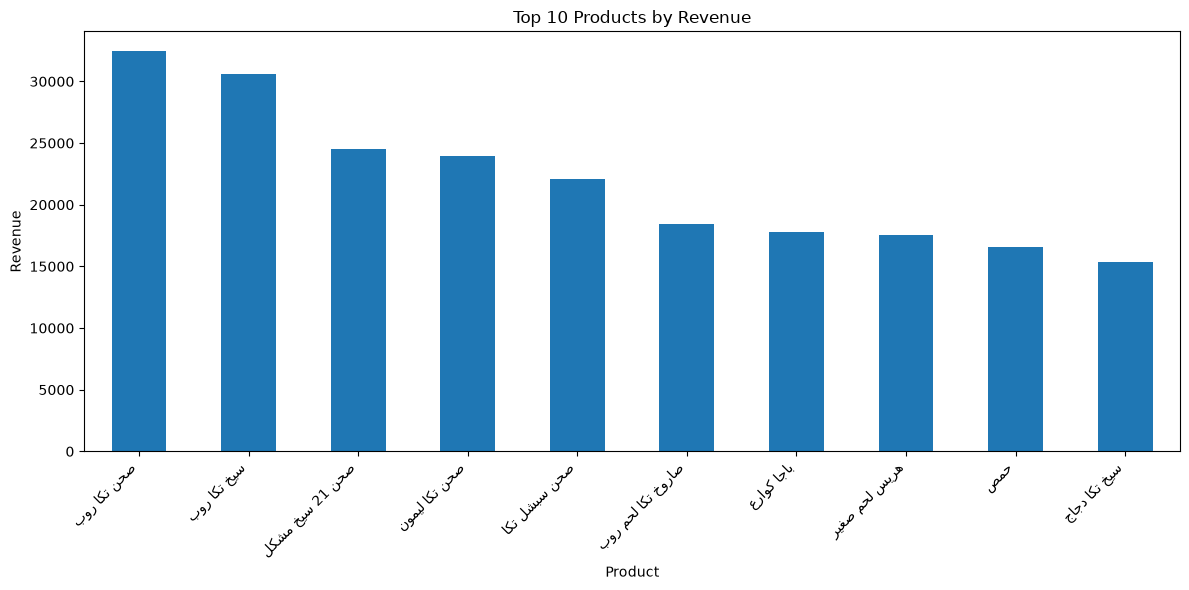

In [36]:
plt.figure(figsize=(12, 6))

top_revenue_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.2 Top 10 Products by Quantity Sold

Visualize the ten products with the highest sales volume.

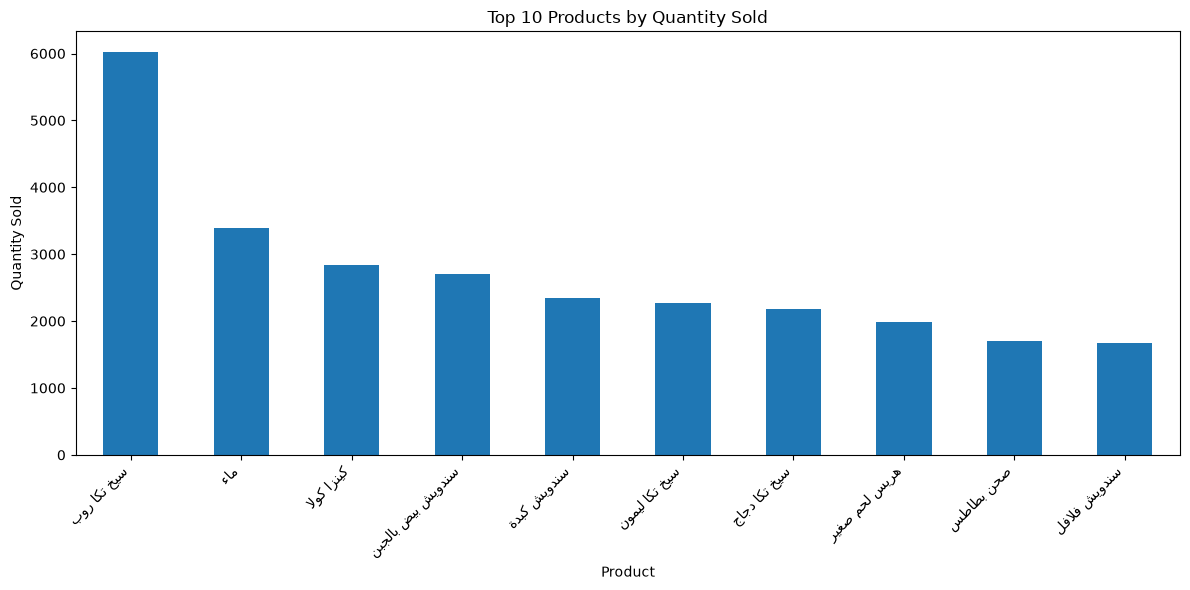

In [37]:
plt.figure(figsize=(12, 6))

top_quantity_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.3 Lowest-Selling Products

Visualize the products with the lowest sales quantity.

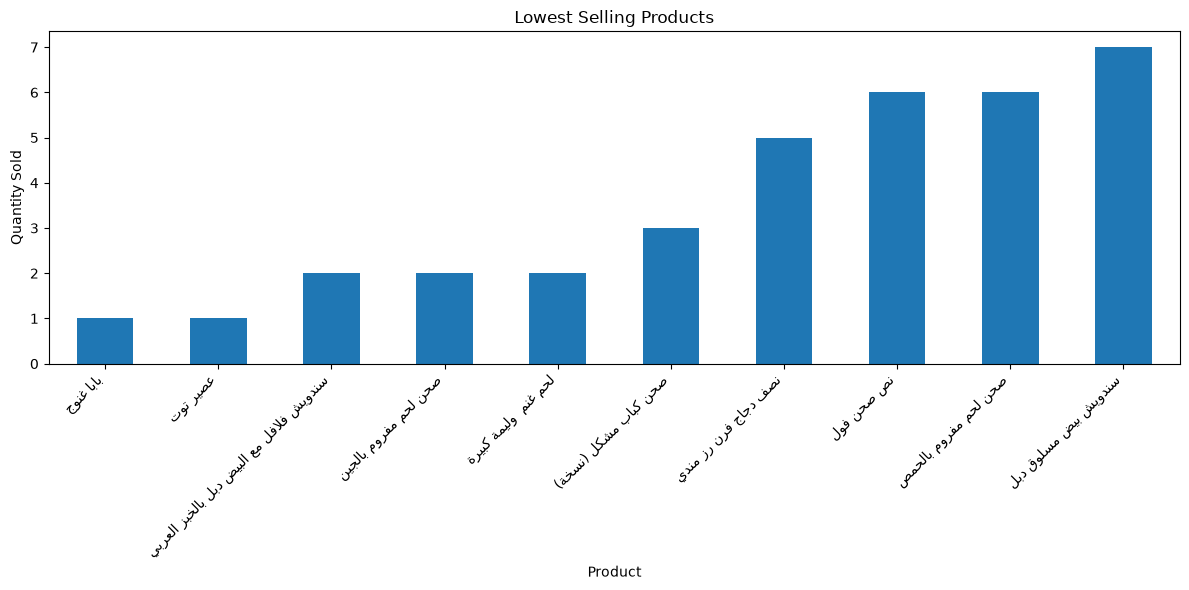

In [38]:
plt.figure(figsize=(12, 6))

lowest_products.head(10).plot(kind="bar")

plt.title("Lowest Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.4 Most Returned Products

Visualize the products with the highest number of returned items.

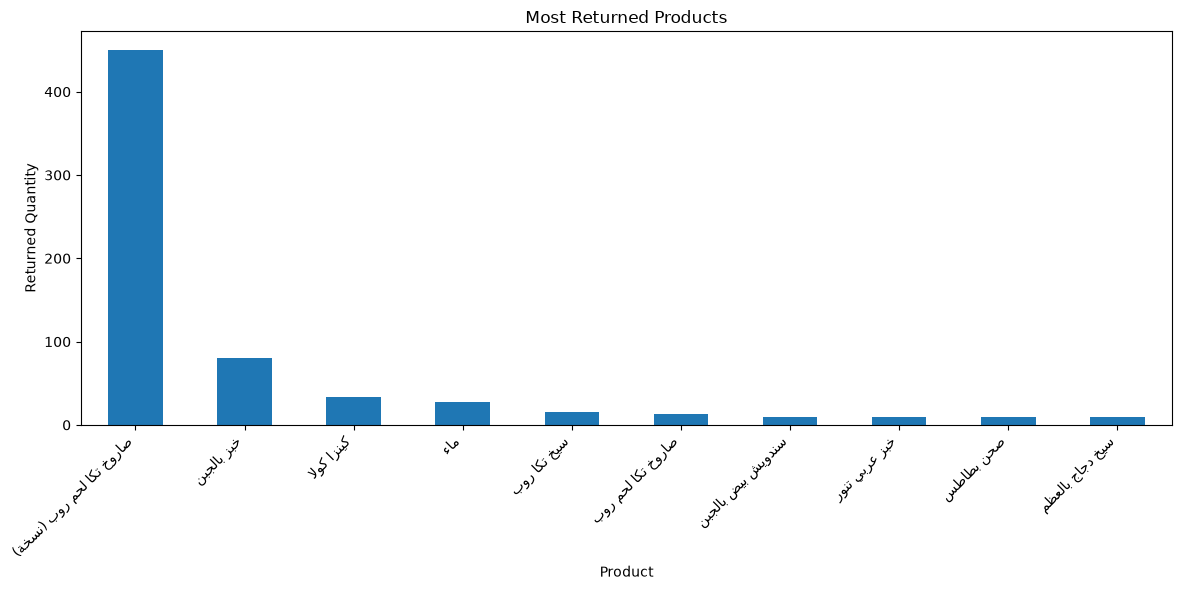

In [39]:
plt.figure(figsize=(12, 6))

returned_products.head(10).plot(kind="bar")

plt.title("Most Returned Products")
plt.xlabel("Product")
plt.ylabel("Returned Quantity")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.5 Monthly Sales

Visualize the total sales revenue for each month.

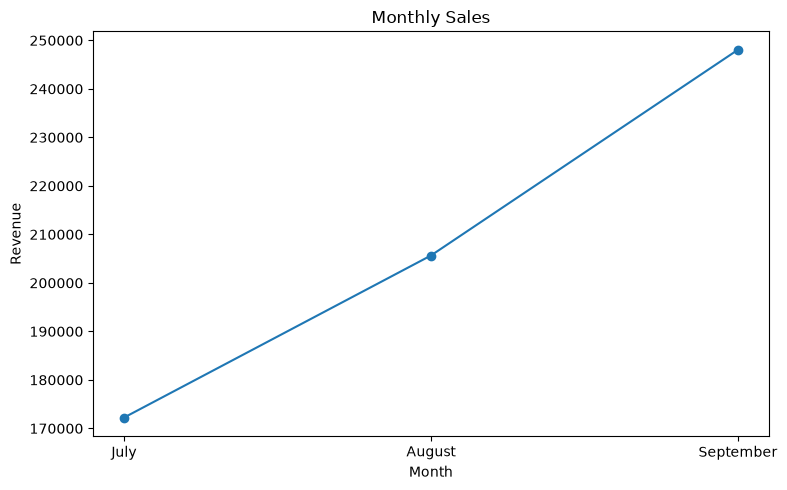

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Subtotal"],
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.6 Sales by Weekday

Visualize sales revenue across the days of the week.

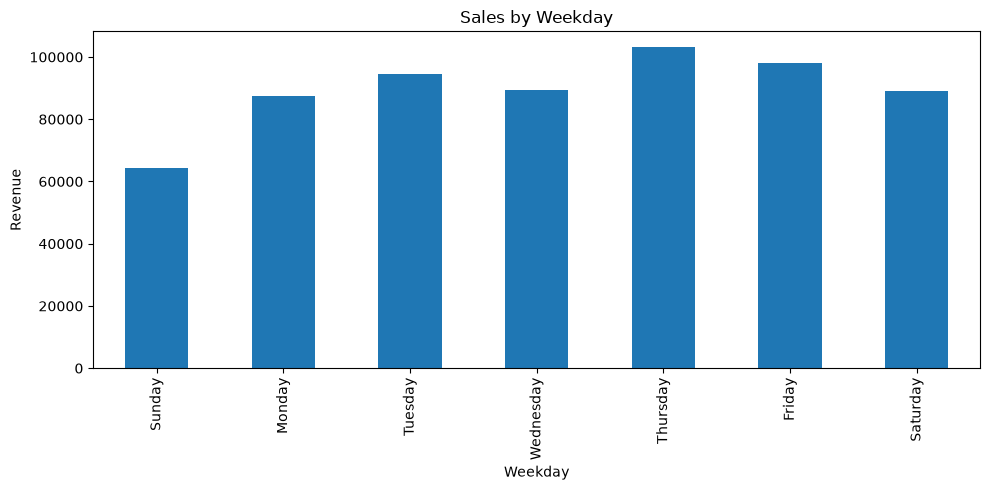

In [41]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.7 Sales by Hour

Visualize hourly sales revenue to identify peak business hours.

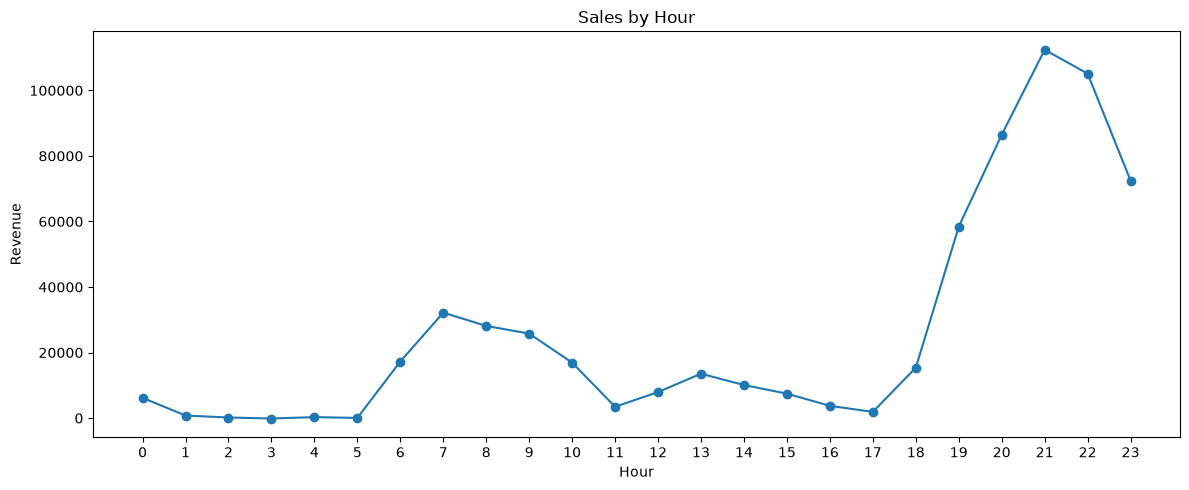

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker="o"
)

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

### 8.8 Revenue by Delivery Platform

Visualize the sales revenue generated by each delivery platform.

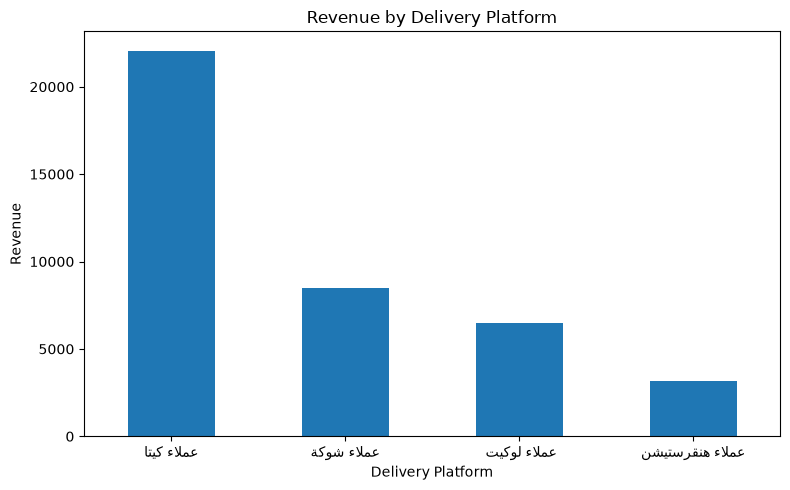

In [43]:
plt.figure(figsize=(8, 5))

platform_sales.plot(kind="bar")

plt.title("Revenue by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.9 Orders by Delivery Platform

Visualize the number of orders received from each delivery platform.

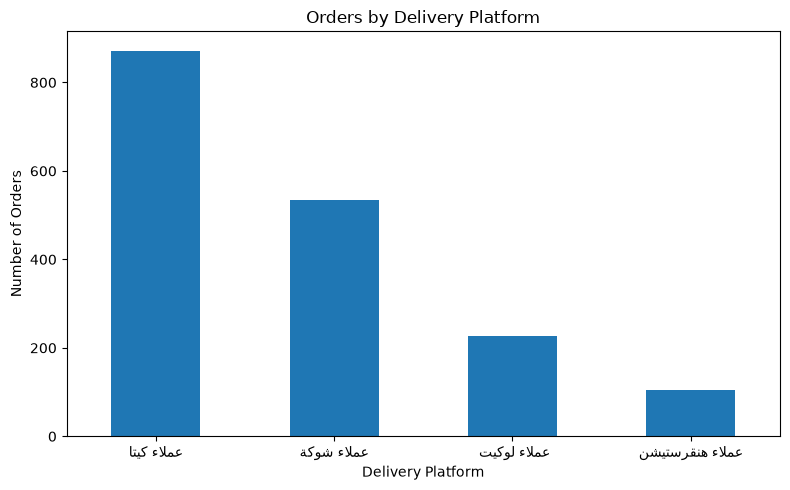

In [44]:
plt.figure(figsize=(8, 5))

platform_orders.plot(kind="bar")

plt.title("Orders by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.10 Delivery Platform Revenue Contribution

Visualize the percentage contribution of each delivery platform to the total sales revenue.

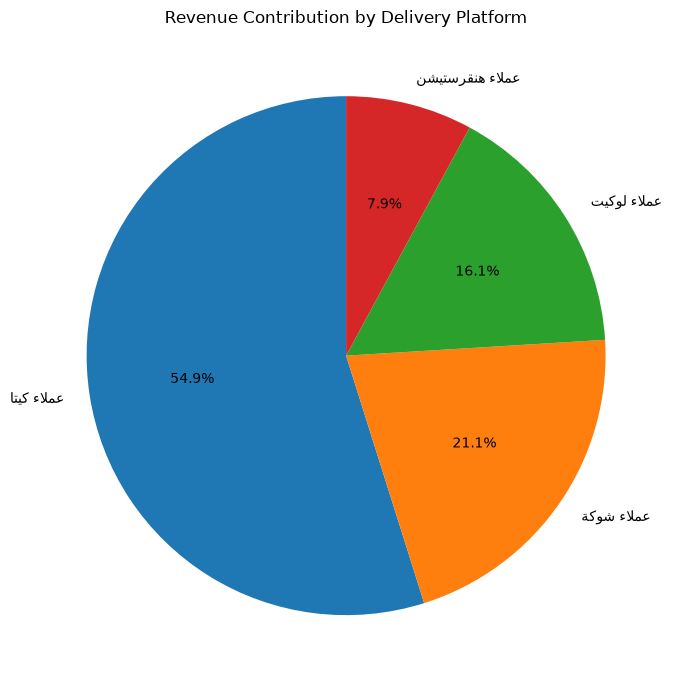

In [45]:
plt.figure(figsize=(7, 7))

plt.pie(
    platform_contribution,
    labels=platform_contribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Delivery Platform")

plt.tight_layout()
plt.show()

## 9. Key Insights

- The third quarter generated a total revenue of **625,920.63** from **15,415** completed orders, with an average order value of **40.60**.
- The cleaned dataset contains **156 unique products**, **638 unique customers**, and **15,415** unique transactions, providing a comprehensive overview of sales activity during the third quarter.
- **September** recorded the highest sales revenue (**248,070.07**) and the highest number of orders (**6,235**), making it the best-performing month of the quarter.
- **Thursday** generated the highest sales revenue, while **Tuesday** recorded the highest number of completed orders, indicating different revenue and ordering patterns across weekdays.
- Sales revenue peaked at **9:00 PM (21:00)**, while the highest number of orders was recorded at **7:00 AM (07:00)**, reflecting different customer purchasing behaviors throughout the day.
- **صحن تكا روب** generated the highest sales revenue, followed by **سيخ تكا روب** and **صحن 21 سيخ مشكل**, making them the leading revenue-generating products during the quarter.
- **سيخ تكا روب** recorded the highest sales quantity, followed by **ماء** and **كينزا كولا**, indicating strong customer demand for these products.
- Among the analyzed delivery platforms, **عملاء كيتا** generated the highest sales revenue, recorded the largest number of completed orders, and achieved the highest average order value during the quarter.
- The highest returned quantities were observed for **صاروخ تكا لحم روب (نسخة)**, **خبز بالجبن**, and **كينزا كولا**, suggesting that these products experienced more returns than other items during the analyzed period.